In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
device

device(type='cuda')

### Downloading APPLE stock details from 2020 to present

In [4]:
ticker='AAPL'
df=yf.download(ticker,'2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [5]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333862,72.394070,71.091169,71.344039,135480400
2020-01-03,71.630623,72.389242,71.406651,71.563190,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861870,72.466353,71.642712,72.211072,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200
...,...,...,...,...,...
2026-07-27,336.910004,339.570007,334.019989,334.540009,49604300
2026-07-28,340.079987,342.890015,335.600006,340.029999,51859000


<Axes: xlabel='Date'>

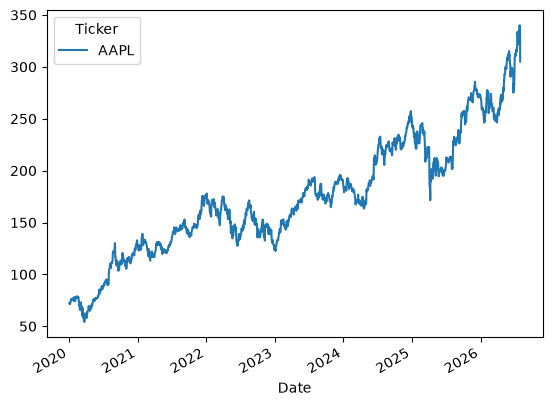

In [6]:
df['Close'].plot()

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform((df['Close']))

In [8]:
seq_len=30
data=[]
for i in range(len(df)-seq_len):
    data.append(scaled_data[i:i+seq_len])

data=np.array(data)
data

array([[[-1.76365123],
        [-1.77575577],
        [-1.7659311 ],
        ...,
        [-1.68066746],
        [-1.64912973],
        [-1.65881153]],

       [[-1.77575577],
        [-1.7659311 ],
        [-1.77177543],
        ...,
        [-1.64912973],
        [-1.65881153],
        [-1.65847902]],

       [[-1.7659311 ],
        [-1.77177543],
        [-1.75187815],
        ...,
        [-1.65881153],
        [-1.65847902],
        [-1.68320223]],

       ...,

       [[ 2.09344198],
        [ 2.14198096],
        [ 2.08535206],
        ...,
        [ 2.72342074],
        [ 2.7903778 ],
        [ 2.84494128]],

       [[ 2.14198096],
        [ 2.08535206],
        [ 2.12080986],
        ...,
        [ 2.7903778 ],
        [ 2.84494128],
        [ 2.81240984]],

       [[ 2.08535206],
        [ 2.12080986],
        [ 2.10359732],
        ...,
        [ 2.84494128],
        [ 2.81240984],
        [ 2.73047795]]], shape=(1623, 30, 1))

In [31]:
train_size=int(0.8*len(data))
X_train=torch.from_numpy(data[:train_size,:-1,:]).type(torch.Tensor).to(device)
y_train=torch.from_numpy(data[:train_size,-1,:]).type(torch.Tensor).to(device)
X_test=torch.from_numpy(data[train_size:,:-1,:]).type(torch.Tensor).to(device)
y_test=torch.from_numpy(data[train_size:,-1,:]).type(torch.Tensor).to(device)

In [10]:
y_train

tensor([[-1.6588],
        [-1.6585],
        [-1.6832],
        ...,
        [ 0.3960],
        [ 0.2517],
        [ 0.3840]], device='cuda:0')

In [11]:
class PredictionModel(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        output_size,
        ##dropout
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
           ##dropout=dropout if num_layers > 1 else 0

        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
           ## nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.ReLU(),
           ## nn.Dropout(dropout),
            nn.Linear(hidden_size // 4, output_size)
        )

    def forward(self, x):
        out, _ = self.lstm(x)

        # Last timestep output
        out = out[:, -1, :]

        out = self.fc(out)

        return out

### Dagshub

In [12]:
import dagshub

dagshub.init(
    repo_owner="astitvamishra0393",
    repo_name="Stock_price_LSTM",
    mlflow=True
)

import os
os.environ["MLFLOW_TRACKING_USERNAME"] = "astitvamishra0393"

os.environ["MLFLOW_TRACKING_PASSWORD"] = "3bd956ae7246a89b696cac2a748b5de5b16083a1"

Accessing as astitvamishra0393

Initialized MLflow to track repo "astitvamishra0393/Stock_price_LSTM"

Repository astitvamishra0393/Stock_price_LSTM initialized!

## Base Model

In [13]:
# Baseline hyperparameters

input_size = X_train.shape[2]
input_size=1
hidden_size = 32
num_layers = 2
output_size = 1

learning_rate = 0.001
epochs = 200
optimizer_name = "Adam"

In [14]:
model=PredictionModel(input_size=input_size,hidden_size=hidden_size,num_layers=num_layers,output_size=output_size).to(device)

In [15]:
import mlflow
mlflow.set_tracking_uri("https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow")

mlflow.set_experiment(
    "Stock_Prediction_LSTM"
)

<Experiment: artifact_location='mlflow-artifacts:/a7959eba3aa34362b10d8ba66fbd544f', creation_time=1785525045317, effective_trace_archival_retention=None, experiment_id='0', last_update_time=1785525045317, lifecycle_stage='active', name='Stock_Prediction_LSTM', tags={}, trace_location=None, workspace='default'>

In [21]:
import torch.optim as optim
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.01)
from sklearn.metrics import root_mean_squared_error,mean_squared_error

Epoch [0/200] Loss: 0.002612
Epoch [20/200] Loss: 0.002591
Epoch [40/200] Loss: 0.002572
Epoch [60/200] Loss: 0.002556
Epoch [80/200] Loss: 0.002543
Epoch [100/200] Loss: 0.002534
Epoch [120/200] Loss: 0.002527
Epoch [140/200] Loss: 0.002523
Epoch [160/200] Loss: 0.002519
Epoch [180/200] Loss: 0.002515
Test Loss: 0.018416
Train RMSE: 2.9119
Test RMSE: 7.8840


2026/08/01 02:25:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/01 02:25:18 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/08/01 02:25:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/08/01 02:25:22 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label

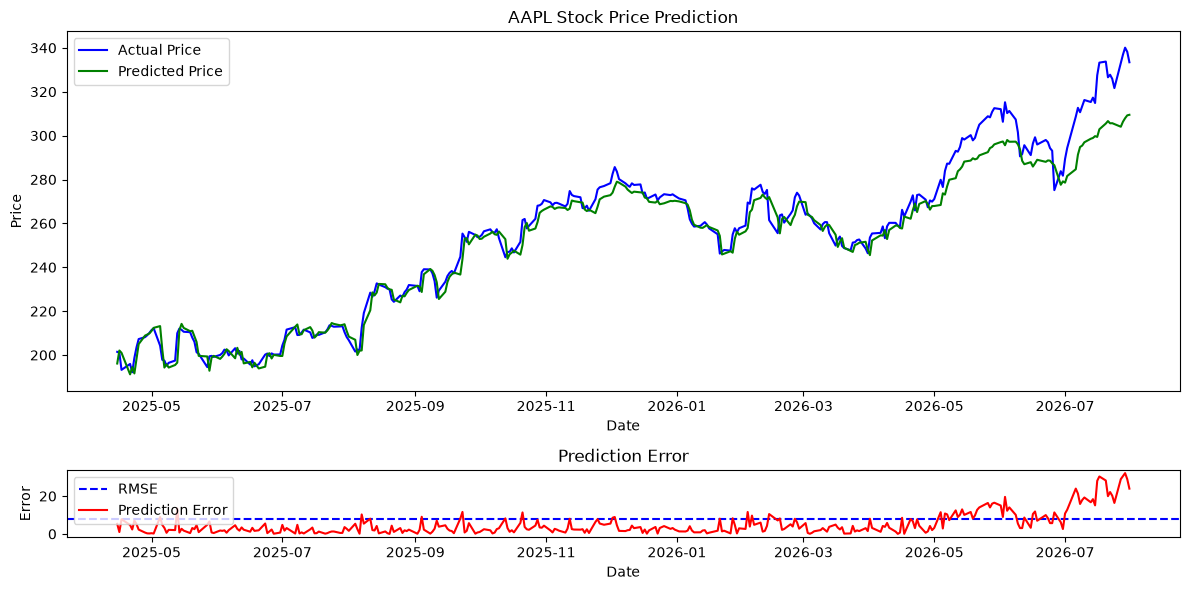

🏃 View run Baseline_LSTM at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/0/runs/816cc3f7a84c403787604e80ae5f8679
🧪 View experiment at: https://dagshub.com/astitvamishra0393/Stock_price_LSTM.mlflow/#/experiments/0


In [32]:
with mlflow.start_run(run_name="Baseline_LSTM"):

    # =========================
    # Log Parameters
    # =========================

    mlflow.log_params({
        "model": "LSTM",
        "hidden_size": hidden_size,
        "num_layers": num_layers,
        "learning_rate": learning_rate,
        "epochs": epochs,
        "optimizer": "Adam",
        "loss_function": "MSELoss"
    })

    # =========================
    # Training
    # =========================

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        y_train_pred = model(X_train)

        loss = criterion(
            y_train_pred,
            y_train
        )

        loss.backward()

        optimizer.step()

        if epoch % 20 == 0:
            print(
                f"Epoch [{epoch}/{epochs}] "
                f"Loss: {loss.item():.6f}"
            )

    # Final training loss

    mlflow.log_metric(
        "train_loss",
        loss.item()
    )

    # =========================
    # Testing
    # =========================

    model.eval()

    with torch.no_grad():

        y_test_pred = model(X_test)

        test_loss = criterion(
            y_test_pred,
            y_test
        )

    print(
        f"Test Loss: {test_loss.item():.6f}"
    )

    mlflow.log_metric(
        "test_loss",
        test_loss.item()
    )

    # =========================
    # Inverse Scaling
    # =========================

    y_train_pred_np = scaler.inverse_transform(
        y_train_pred.detach().cpu().numpy()
    )

    y_test_pred_np = scaler.inverse_transform(
        y_test_pred.detach().cpu().numpy()
    )

    y_train_actual = scaler.inverse_transform(
        y_train.detach().cpu().numpy()
    )

    y_test_actual = scaler.inverse_transform(
        y_test.detach().cpu().numpy()
    )

    # =========================
    # RMSE
    # =========================

    train_rmse = root_mean_squared_error(
        y_train_actual[:, 0],
        y_train_pred_np[:, 0]
    )

    test_rmse = root_mean_squared_error(
        y_test_actual[:, 0],
        y_test_pred_np[:, 0]
    )

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")

    mlflow.log_metric(
        "train_rmse",
        train_rmse
    )

    mlflow.log_metric(
        "test_rmse",
        test_rmse
    )

    # =========================
    # Prediction Plot
    # =========================

    figure = plt.figure(figsize=(12, 6))

    gs = figure.add_gridspec(4, 1)

    # Price Plot
    ax1 = figure.add_subplot(gs[:3, 0])

    ax1.plot(
        df.iloc[-len(y_test_actual):].index,
        y_test_actual,
        color="blue",
        label="Actual Price"
    )

    ax1.plot(
        df.iloc[-len(y_test_actual):].index,
        y_test_pred_np,
        color="green",
        label="Predicted Price"
    )

    ax1.set_title(
        f"{ticker} Stock Price Prediction"
    )

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Price")
    ax1.legend()

    # Error Plot
    ax2 = figure.add_subplot(gs[3, 0])

    ax2.axhline(
        test_rmse,
        color="blue",
        linestyle="--",
        label="RMSE"
    )

    ax2.plot(
        df.iloc[-len(y_test_actual):].index,
        abs(
            y_test_actual.flatten()
            - y_test_pred_np.flatten()
        ),
        color="red",
        label="Prediction Error"
    )

    ax2.set_title("Prediction Error")
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Error")
    ax2.legend()

    plt.tight_layout()

    # =========================
    # Log Figure
    # =========================

    mlflow.log_figure(
        figure,
        "baseline_prediction.png"
    )

    # =========================
    # Save Model
    # =========================

    mlflow.pytorch.log_model(
        model,
        "baseline_model",
        serialization_format="pickle"
    )

    plt.show()